# From Forecasts to Decisions: Computational Companion

**Rishi Ashish Shah, Sara Hajihashemi, Janet K. Allen, Farrokh Mistree**
Systems Realization Laboratory, University of Oklahoma

This notebook reproduces every number, table and figure reported in the manuscript. We
execute the cells in the order in which the corresponding results appear in the paper, and
we name the section of the paper that each result supports.

**Research question.** How can designers systematically connect forecast-informed
quantities, evidence about data credibility and model sensitivity, and stakeholder-defined
requirements to support traceable satisficing-based configuration decisions under
uncertainty?

**What the procedure does.** Through the procedure, designers separate two determinations
that are commonly combined. First, designers fix the *role* a quantity plays in the decision:
a fixed input, a decision variable, a bound, a non-negotiable requirement, a desired target,
or a scenario. Second, designers fix how to *use the value* of that quantity, according to
the credibility of its data and the sensitivity of its forecast to defensible modelling
choices. We use the compromise Decision Support Problem as the formal satisficing construct
for the demonstration.

**Contents**

| Section here | Paper section | Content |
|---|---|---|
| 1 | 5.3 | Provenance of every input |
| 2 | 3 | The two mapping decisions |
| 3 | 4.1, 4.2 | Classifying credibility and model-form sensitivity |
| 4 | 4.3, 4.4 | The response table and its operational actions |
| 5 | 5.1, 5.5 | Scope and the system model |
| 6 | 5.4 | The demand value and our own forecast |
| 7 | 5.7 | The stakeholder requirements and their derivations |
| 8 | 6.1, 7.1 | Candidate configurations and Stage 1 screening |
| 9 | 7.2 | Stage 2, the satisfactory configuration |
| 10 | 7.3 | Comparison with four simpler decision rules |
| 11 | 7.4 | Verification and reduction to screening |
| 12 | 7.5 | Demand scenarios and the limit of feasibility |
| 13 | 7.6 | The solar capacity factor across model forms |
| 14 | 7.7, 7.8 | Trade-off frontier and the goal weights |
| 15 | 7.9 | The four ablations |
| 16 | 8 | The traceable record |
| 17 | 7 | Figures |

Repository: https://github.com/RS-010806/forecast-informed-cdsp

## 1. Provenance of every input (paper Section 5.3)

We take every engineering value from a documented public source. The evidence class states
what kind of support each value carries: a measurement reported for Iran, a global
representative value used because no Iranian value is published, a value we adjusted for an
Iranian condition, a value we calibrated so the model reproduces a reported national
aggregate, a forecast we produced ourselves, a forecast from an external study, or a stated
policy target. Each class carries a different credibility level, and designers treat it
accordingly.

In [1]:
import numpy as np, pandas as pd, pulp
import iran_cdsp as M

pd.set_option("display.max_colwidth", 78)
pd.set_option("display.width", 190)

provenance = pd.DataFrame(
    [(k, v[0], v[2], v[1]) for k, v in M.PROVENANCE.items()],
    columns=["Quantity", "Value", "Evidence class", "Documented source"])
provenance

,Quantity,Value,Evidence class,Documented source
0,Installed hydro capacity,11.781 GW,measured-national,"IRENA Renewable Capacity Statistics 2025, Iran, year-end 2024, renewable h..."
1,Installed solar PV capacity,0.782 GW,measured-national,"IRENA Renewable Capacity Statistics 2025, Iran, year-end 2024"
2,Installed geothermal capacity,0.0 GW,measured-national,"IRENA Renewable Capacity Statistics 2025, no Iranian geothermal entry"
3,Installed biofuel capacity,0.022 GW,measured-national,"IRENA Renewable Capacity Statistics 2025, Iran, year-end 2024, biogas"
4,Installed thermal capacity,77.0 GW,measured-national,"Iran Thermal Power Plants Holding Company, reported via Tehran Times 2024:..."
5,Hydro capacity factor,0.18,adjusted,Adjusted downward for prolonged drought. The IRENA global hydro capacity f...
6,Solar PV capacity factor,0.162,global-proxy,"IRENA Renewable Power Generation Costs in 2023, global weighted average, u..."
7,Geothermal capacity factor,0.821,global-proxy,"IRENA Renewable Power Generation Costs in 2023, global weighted average, g..."
8,Biofuel capacity factor,0.719,global-proxy,"IRENA Renewable Power Generation Costs in 2023, global weighted average, b..."
9,Gas capacity factor,0.524,calibrated,Calibrated so the existing thermal fleet reproduces the IRENA-reported 202...


## 2. The two mapping decisions (paper Section 3)

Designers make two determinations, and we keep them separate. Designers settle the **role**
of a quantity by its function in the problem, not by how well researchers know it. Designers
settle the **use of its value** by how far the data and the forecast can be trusted.

Keeping the two apart prevents a designer from treating a well-measured quantity as a
non-negotiable requirement merely because researchers measured it well. Meeting demand is a
rigid requirement whatever the confidence; the demand *value* is uncertain, so we vary it
across five scenarios in Section 12 below.

In [2]:
pd.DataFrame([
 ["Demand coverage", "Non-negotiable requirement", "Rigid constraint", "Role"],
 ["2030 demand value", "Uncertain level of that requirement", "Constraint level, varied across five scenarios", "Confidence"],
 ["New capacity per technology", "Quantity the designer selects", "Decision variable", "Role"],
 ["2030 build limit per technology", "Limit on what designers can build", "Upper bound on the decision variable", "Role"],
 ["Renewable share", "Desired target", "Goal with a pair of deviation variables", "Role"],
 ["Emissions", "Desired target", "Goal with a pair of deviation variables", "Role"],
 ["Annualised cost", "Desired target", "Goal with a pair of deviation variables", "Role"],
 ["Solar capacity factor", "Highly sensitive forecast input", "Coefficient, tested across three model forms", "Confidence"],
 ["Existing thermal capacity", "Fixed background", "Fixed input, not a decision variable", "Role"],
], columns=["Quantity", "Role in the decision", "Representation in the compromise DSP", "Determined by"])

,Quantity,Role in the decision,Representation in the compromise DSP,Determined by
0,Demand coverage,Non-negotiable requirement,Rigid constraint,Role
1,2030 demand value,Uncertain level of that requirement,"Constraint level, varied across five scenarios",Confidence
2,New capacity per technology,Quantity the designer selects,Decision variable,Role
3,2030 build limit per technology,Limit on what designers can build,Upper bound on the decision variable,Role
4,Renewable share,Desired target,Goal with a pair of deviation variables,Role
5,Emissions,Desired target,Goal with a pair of deviation variables,Role
6,Annualised cost,Desired target,Goal with a pair of deviation variables,Role
7,Solar capacity factor,Highly sensitive forecast input,"Coefficient, tested across three model forms",Confidence
8,Existing thermal capacity,Fixed background,"Fixed input, not a decision variable",Role


## 3. Classifying credibility and model-form sensitivity (paper Sections 4.1 and 4.2)

For other researchers to apply the response table consistently, both classifications need
stated criteria rather than intuition.

**Data credibility.** Researchers consider the source and its authority, the completeness of
the observations, the consistency of the records, the temporal coverage relative to the
planning horizon, the directness of measurement, the transformations required, and the
dependence on proxy or derived information.

**Model-form sensitivity.** Researchers fit a retained model, a defensible alternate model
and a conservative model to the same data, compare the values they yield for the planning
year, and consider both the spread and whether differences of that size materially change
the configuration evaluation.

In [3]:
credibility = pd.DataFrame([
 ["High", "An authoritative source reports the quantity directly for the system under study; records complete and consistent; few transformations; no proxy dependence.", "Installed thermal capacity, 77.0 GW"],
 ["Medium", "A recognised source reports it, but for a broader population, or with gaps, shorter coverage, or required transformations; partial proxy dependence.", "Solar capacity factor, 0.162, a global average"],
 ["Low", "No authoritative source reports it for the system under study; inferred from sparse, inconsistent or indirect observations, or from an uncertain proxy.", "None used here; see the excluded technologies"],
], columns=["Level", "Conditions that place a quantity at this level", "Example"])

sensitivity = pd.DataFrame([
 ["Low", "Retained, alternate and conservative models agree closely; differences do not change which configurations satisfy the requirements.", "Installed capacity, observed rather than forecast"],
 ["Moderate", "Models differ appreciably, but designers reach configurations satisfying the same requirements across that range.", "2030 electricity demand"],
 ["High", "Models differ enough that designers would reach a materially different configuration, or acceptance changes across forms.", "Solar photovoltaic output"],
], columns=["Level", "Conditions that place a quantity at this level", "Example"])

display(credibility); display(sensitivity)

,Level,Conditions that place a quantity at this level,Example
0,High,An authoritative source reports the quantity directly for the system under...,"Installed thermal capacity, 77.0 GW"
1,Medium,"A recognised source reports it, but for a broader population, or with gaps...","Solar capacity factor, 0.162, a global average"
2,Low,No authoritative source reports it for the system under study; inferred fr...,None used here; see the excluded technologies


,Level,Conditions that place a quantity at this level,Example
0,Low,"Retained, alternate and conservative models agree closely; differences do ...","Installed capacity, observed rather than forecast"
1,Moderate,"Models differ appreciably, but designers reach configurations satisfying t...",2030 electricity demand
2,High,Models differ enough that designers would reach a materially different con...,Solar photovoltaic output


## 4. The response table and its operational actions (paper Sections 4.3 and 4.4)

Designers enter the table by the credibility level and the sensitivity level, and read off
the action to take on the value. Each action then needs an operational description, in
particular the rule for widening a value and the condition under which testing across model
forms provides sufficient evidence.

In [4]:
response = pd.DataFrame(
 [["Use as reported", "Use, and record the sensitivity", "Use, and test across model forms"],
  ["Use with a stated caution", "Widen the value", "Widen the value and test across model forms"],
  ["Qualify the value", "Qualify and widen the value", "Flag the value; test across model forms or defer"]],
 index=["High data credibility", "Medium data credibility", "Low data credibility"],
 columns=["Low model-form sensitivity", "Moderate model-form sensitivity", "High model-form sensitivity"])
display(response)

actions = pd.DataFrame([
 ["Use as reported", "Enter the reported value without adjustment; record the source in the traceable record."],
 ["Use, and record the sensitivity", "Enter the reported value; record the spread across model forms so a reviewer sees the exposure."],
 ["Use with a stated caution", "Enter the value; state the specific limitation of the source in the text."],
 ["Widen the value", "Replace the single value with an interval: the combined range across retained, alternate and conservative results, extended to the reported uncertainty interval where available. Otherwise apply and state a documented adjustment rule."],
 ["Qualify the value", "Use the value only in a role where an error does not invalidate the decision, that is, as a target rather than a rigid constraint."],
 ["Test across model forms", "Solve once per defensible model form and compare. Sufficient when the configurations satisfy the same requirements across all forms; insufficient when acceptance changes across forms, in which case designers need additional information."],
 ["Flag the value; defer", "Record as unresolved, exclude from the requirements determining acceptance, and state what evidence would admit it."],
], columns=["Action", "What designers do"])
display(actions)

,Low model-form sensitivity,Moderate model-form sensitivity,High model-form sensitivity
High data credibility,Use as reported,"Use, and record the sensitivity","Use, and test across model forms"
Medium data credibility,Use with a stated caution,Widen the value,Widen the value and test across model forms
Low data credibility,Qualify the value,Qualify and widen the value,Flag the value; test across model forms or defer


,Action,What designers do
0,Use as reported,Enter the reported value without adjustment; record the source in the trac...
1,"Use, and record the sensitivity",Enter the reported value; record the spread across model forms so a review...
2,Use with a stated caution,Enter the value; state the specific limitation of the source in the text.
3,Widen the value,Replace the single value with an interval: the combined range across retai...
4,Qualify the value,Use the value only in a role where an error does not invalidate the decisi...
5,Test across model forms,Solve once per defensible model form and compare. Sufficient when the conf...
6,Flag the value; defer,"Record as unresolved, exclude from the requirements determining acceptance..."


## 5. Scope and the system model (paper Sections 5.1 and 5.5)

We model the Iranian national electricity system for 2030 as an annual energy-balance and
capacity-planning problem. Hourly dispatch, transmission, storage operation, reserve margins
and regional differences lie outside this boundary.

Added renewable generation displaces gas rather than adding to it, so we compute gas
generation as the residual needed to meet demand after renewables, capped by the maximum the
fixed fleet can supply. Through this treatment, emissions and cost respond to the decision.
We report in Section 15 what a designer loses by omitting it.

In [5]:
D = M.demand_design_value("point")
print(f"Existing renewable generation      : {M.renewable_generation({}):8.2f} TWh/yr")
print(f"Gas fleet maximum output           : {M.gas_max_generation():8.2f} TWh/yr")
print(f"Existing system total              : {M.renewable_generation({}) + M.gas_max_generation():8.2f} TWh/yr")
print(f"Maximum 2030 system generation     : {M.max_system_generation():8.2f} TWh/yr")
print(f"Central 2030 demand projection     : {D:8.2f} TWh/yr")
print()
print("The existing system cannot meet the projected demand, so the decision is substantive:")
print(f"  shortfall without new capacity   : {D - (M.renewable_generation({}) + M.gas_max_generation()):8.2f} TWh/yr")

Existing renewable generation      :    19.82 TWh/yr
Gas fleet maximum output           :   353.45 TWh/yr
Existing system total              :   373.27 TWh/yr
Maximum 2030 system generation     :   414.36 TWh/yr
Central 2030 demand projection     :   389.76 TWh/yr

The existing system cannot meet the projected demand, so the decision is substantive:
  shortfall without new capacity   :    16.49 TWh/yr


## 6. The demand value and our own forecast (paper Section 5.4)

Two forecasts are available to us, and a reader should know which is which. In the
forecasting stage of this research programme we produced approximately 377.1 TWh from the
project dataset. For this demonstration we selected the externally reported Iran-specific
projection of approximately 389.8 TWh, which also supplies the interval and the emissions
trajectory we use elsewhere.

We use 389.76 TWh as the central planning value and retain 377.1 TWh as a comparison and
plausibility check. We solve at both values in Section 12.

In [6]:
ext, own = M.DEMAND["point"], M.DEMAND["own_forecast"]
diff = ext - own
print(f"External Iran-specific projection  : {ext:.2f} TWh/yr")
print(f"Our own 2030 forecast              : {own:.2f} TWh/yr")
print(f"Difference                         : {diff:.2f} TWh/yr = {diff/own*100:.2f}% of our own forecast")
print(f"Reported interval of the external study: [{M.DEMAND['ci_low']:.2f}, {M.DEMAND['ci_high']:.2f}] TWh/yr")
print(f"Our forecast lies inside that interval : {M.DEMAND['ci_low'] <= own <= M.DEMAND['ci_high']}")

External Iran-specific projection  : 389.76 TWh/yr
Our own 2030 forecast              : 377.10 TWh/yr
Difference                         : 12.66 TWh/yr = 3.36% of our own forecast
Reported interval of the external study: [363.64, 408.50] TWh/yr
Our forecast lies inside that interval : True


## 7. The stakeholder requirements and their derivations (paper Section 5.7)

We derive every requirement level from a documented source rather than choosing it. The
renewable-share level is supported by two independent policy instruments that converge, and
we compute both derivations here.

In [7]:
thr = M.thresholds_for(D)

# Derivation 1: the 30 GW national capacity target
exist_ren = sum(M.K_EXIST[t] for t in M.CANDIDATES)
headroom = 30.0 - exist_ren
scale = headroom / sum(M.K_ADD_MAX.values())
mix = {t: M.K_ADD_MAX[t] * scale for t in M.CANDIDATES}
gen_at_target = sum(M.energy_twh(M.CF[t], M.K_EXIST[t] + mix[t]) for t in M.CANDIDATES)

# Derivation 2: the unconditional Paris commitment
ceiling = M.emissions_ceiling(D)
gas_allowed = ceiling / M.EMIT["gas_fixed"]
ren_needed = D - gas_allowed

print("Renewable-share requirement, two independent derivations")
print(f"  Existing renewable capacity            : {exist_ren:.3f} GW")
print(f"  Headroom under the 30 GW target        : {headroom:.3f} GW")
print(f"  Generation at the target               : {gen_at_target:.2f} TWh/yr")
print(f"  Implied renewable share                : {gen_at_target/D*100:.1f}%")
print(f"  Paris unconditional ratio              : {M.PARIS_UNCOND_RATIO:.4f} (a 4.0% reduction against trend)")
print(f"  Implied emissions ceiling              : {ceiling:.2f} Mt/yr")
print(f"  Renewable share that ceiling requires  : {ren_needed/D*100:.1f}%")
print(f"  Adopted requirement                    : {thr['renewable_share']['target']*100:.0f}%, consistent with both")
print()
cond_ceiling = M.all_gas_baseline_emissions(D) * M.PARIS_COND_RATIO
cond_share = (D - cond_ceiling / M.EMIT["gas_fixed"]) / D * 100
print("The conditional Paris commitment, by contrast, is not reachable here")
print(f"  Conditional ceiling                    : {cond_ceiling:.2f} Mt/yr")
print(f"  Renewable share it requires            : {cond_share:.1f}%")
print(f"  Maximum share within the build limits  : {M.max_renewable_generation()/D*100:.1f}%")
print()
pd.DataFrame([
 ["Demand coverage", M.THRESHOLDS["demand_coverage"]["priority"], "Renewables plus the full gas fleet must meet the design demand"],
 ["Renewable share", M.THRESHOLDS["renewable_share"]["priority"], f"At least {thr['renewable_share']['target']*100:.0f} percent of annual generation"],
 ["Emissions", M.THRESHOLDS["emissions"]["priority"], f"At most {ceiling:.2f} Mt CO2 per year"],
 ["Annualised cost", M.THRESHOLDS["cost"]["priority"], f"At most {thr['cost']['target']:.1f} billion USD per year"],
], columns=["Requirement", "Priority", "Level"])

Renewable-share requirement, two independent derivations
  Existing renewable capacity            : 12.585 GW
  Headroom under the 30 GW target        : 17.415 GW
  Generation at the target               : 52.65 TWh/yr
  Implied renewable share                : 13.5%
  Paris unconditional ratio              : 0.9600 (a 4.0% reduction against trend)
  Implied emissions ceiling              : 166.26 Mt/yr
  Renewable share that ceiling requires  : 12.9%
  Adopted requirement                    : 13%, consistent with both

The conditional Paris commitment, by contrast, is not reachable here
  Conditional ceiling                    : 152.40 Mt/yr
  Renewable share it requires            : 20.2%
  Maximum share within the build limits  : 15.6%



,Requirement,Priority,Level
0,Demand coverage,critical,Renewables plus the full gas fleet must meet the design demand
1,Renewable share,important,At least 13 percent of annual generation
2,Emissions,important,At most 166.26 Mt CO2 per year
3,Annualised cost,desirable,At most 28.8 billion USD per year


## 8. Candidate configurations and Stage 1 screening (paper Sections 6.1 and 7.1)

We construct four named configurations by stated rules, so a reader can see how we formed
each rather than treating the capacities as arbitrary. We then screen each against the
requirements: we reject a configuration that fails the critical requirement, flag one that
misses an important requirement, and accept one that meets every requirement.

In [8]:
cfg = M.config_table()
display(cfg[["Configuration"] + [f"{M.TECH_LABEL[t]} (GW)" for t in M.CANDIDATES] + ["Total added (GW)"]])
for name, rule in M.CONFIG_RULES.items():
    print(f"{name}:\n  {rule}\n")

,Configuration,Solar PV (GW),Hydro (GW),Geothermal (GW),Biofuel (GW),Total added (GW)
0,Current-Trend,4.0,0.5,0.0,0.1,4.6
1,Renewable-Priority,15.0,2.5,0.8,0.6,18.9
2,Balanced-Transition,11.0,2.0,0.5,0.4,13.9
3,Firm-Capacity,7.0,1.0,0.2,0.2,8.4


Current-Trend:
  Continuation of the recent pace of renewable additions. Iranian solar additions have run near 0.8 GW per year, which over the five years to 2030 gives 4.0 GW of solar. We add the small hydro and biogas increments already under construction and no geothermal, because no Iranian geothermal plant is currently in development.

Renewable-Priority:
  A build close to the ceiling implied by the national target. We set each technology near 90 percent of its 2030 build limit, giving 15.0 GW of solar, 2.5 GW of hydro, 0.8 GW of geothermal and 0.6 GW of biofuel.

Balanced-Transition:
  An intermediate build spread across all four candidate technologies. We set each technology near 60 percent of its build limit, giving 11.0 GW of solar, 2.0 GW of hydro, 0.5 GW of geothermal and 0.4 GW of biofuel.

Firm-Capacity:
  A reliability-first build that leans on the dispatchable gas fleet. We halve the Balanced-Transition solar figure to 7.0 GW and reduce the other technologies in proporti

In [9]:
screening = M.screening_table()
display(screening.drop(columns=["Reason"]))
for row in screening.itertuples():
    print(f"  {row.Configuration:22s} {row.Outcome:12s} {row.Reason}")

,Configuration,New capacity (GW),Generation (TWh/yr),Renewable share (%),Emissions (Mt/yr),Cost (bn USD/yr),Outcome
0,Current-Trend,4.6,380.4,7.1,173.2,28.32,Rejected
1,Renewable-Priority,18.9,389.8,14.0,164.2,28.43,Acceptable
2,Balanced-Transition,13.9,389.8,11.5,169.1,28.65,Flagged
3,Firm-Capacity,8.4,387.5,8.8,173.2,28.70,Rejected


  Current-Trend          Rejected     fails critical: demand coverage; misses important: renewable share, emissions
  Renewable-Priority     Acceptable   meets every requirement
  Balanced-Transition    Flagged      misses important: renewable share, emissions
  Firm-Capacity          Rejected     fails critical: demand coverage; misses important: renewable share, emissions


## 9. Stage 2: the satisfactory configuration (paper Section 7.2)

In the second stage we search the full space of allowable configurations. We are not
restricted to the four named configurations: we select the new capacities as continuous
quantities, so a configuration that no one proposed in advance can result.

All three deviation-function forms return the same configuration here. That is a property of
the case, not of the construct: in the documented cost data every renewable technology is
cheaper per unit of energy than gas, so raising the renewable share also lowers cost and the
two goals are aligned rather than competing. We show in Section 14 that the forms separate
once the goals genuinely compete.

In [10]:
w  = M.solve_cdsp("point", "weighted")
p1 = M.solve_cdsp("point", "priority", priorities=("renewable", "emissions", "cost"))
p2 = M.solve_cdsp("point", "priority", priorities=("cost", "emissions", "renewable"))
display(pd.DataFrame([
    M.solution_row(w,  "Weighted, equal weights"),
    M.solution_row(p1, "Priority: renewable, emissions, cost"),
    M.solution_row(p2, "Priority: cost, emissions, renewable"),
]).set_index("Solution"))

print("Why the three forms coincide: every renewable is cheaper per MWh than gas")
display(M.goal_alignment_note())

,Solar PV (GW),Hydro (GW),Geothermal (GW),Biofuel (GW),Total added (GW),Renewable share (%),Emissions (Mt/yr),Cost (bn USD/yr)
Solution,,,,,,,,
"Weighted, equal weights",9.78,3.0,1.0,0.8,14.58,13.0,166.2,28.64
"Priority: renewable, emissions, cost",9.78,3.0,1.0,0.8,14.58,13.0,166.2,28.64
"Priority: cost, emissions, renewable",9.78,3.0,1.0,0.8,14.58,13.0,166.2,28.64


Why the three forms coincide: every renewable is cheaper per MWh than gas


,Technology,Levelised cost (USD/MWh),Cheaper than gas
0,Solar PV,44.0,True
1,Hydro,57.0,True
2,Geothermal,71.0,True
3,Biofuel,72.0,True
4,Gas (fixed),76.0,False


## 10. Comparison with four simpler decision rules (paper Section 7.3)

A reader may reasonably ask what the procedure adds over rules a designer could apply
without it. Each baseline represents a way a designer might proceed in the absence of a
structured procedure.

In [11]:
baselines = M.baseline_comparison()
display(baselines.drop(columns=["What the designer gives up"]))

cdsp = baselines.loc[baselines["Decision rule"] == "Compromise DSP", "Total added (GW)"].iloc[0]
lc   = baselines.loc[baselines["Decision rule"] == "Least cost only", "Total added (GW)"].iloc[0]
bs   = baselines.loc[baselines["Decision rule"] == "Best screened configuration", "Total added (GW)"].iloc[0]
print(f"The compromise solution satisfies every requirement while committing:")
print(f"  {(1-cdsp/lc)*100:.0f}% less new capacity than the least-cost rule   ({cdsp:.2f} against {lc:.2f} GW)")
print(f"  {(1-cdsp/bs)*100:.0f}% less new capacity than screening alone       ({cdsp:.2f} against {bs:.2f} GW)")

,Decision rule,Total added (GW),Renewable share (%),Emissions (Mt/yr),Cost (bn USD/yr),Requirements satisfied
0,Least cost only,21.80,15.6,161.1,28.31,3 of 3
1,Minimum new capacity,4.50,9.3,173.2,29.10,"0 of 3 (misses renewable share, emissions, cost)"
2,Pro-rata scaling,NaN,NaN,NaN,NaN,No feasible result
3,Best screened configuration,18.90,14.0,164.2,28.43,3 of 3
4,Compromise DSP,14.58,13.0,166.2,28.64,3 of 3


The compromise solution satisfies every requirement while committing:
  33% less new capacity than the least-cost rule   (14.58 against 21.80 GW)
  23% less new capacity than screening alone       (14.58 against 18.90 GW)


## 11. Verification and reduction to screening (paper Section 7.4)

We verify the reported solution against the conditions a compromise solution must satisfy:
each goal equation holds in its normalised form, at most one deviation of each pair is
positive, every deviation is non-negative, and the generation delivered meets the demand.

We then confirm that when we treat every requirement as rigid, the set the compromise DSP
admits as feasible is exactly the set the screening stage accepts. The compromise formulation
therefore extends the screening procedure rather than replacing it.

In [12]:
display(M.verify(w))
print("Every verification condition satisfied:", bool(M.verify(w)["Satisfied"].all()))
print()
red = M.reduction_check()
display(red)
print("Rigid-requirement set agrees with the screened set on every configuration:", bool(red["Agreement"].all()))

,Quantity,Computed,Required,Satisfied
0,Renewable-share goal equation residual,6.80e-08,0,True
1,Emissions goal equation residual,1.000000,1,True
2,Cost goal equation residual,1.000000,1,True
3,Product of the two renewable deviations,0.00e+00,0,True
4,Product of the two emissions deviations,0.00e+00,0,True
5,Product of the two cost deviations,0.00e+00,0,True
6,All deviation variables non-negative,yes,yes,True
7,Generation at least demand (TWh/yr),389.76 against 389.76,at least,True


Every verification condition satisfied: True



,Configuration,Admitted when every requirement is rigid,Accepted in the screening stage,Agreement
0,Current-Trend,False,False,True
1,Renewable-Priority,True,True,True
2,Balanced-Transition,False,False,True
3,Firm-Capacity,False,False,True


Rigid-requirement set agrees with the screened set on every configuration: True


## 12. Demand scenarios and the limit of feasibility (paper Section 7.5)

Researchers classify the 2030 demand as high credibility and moderate model-form
sensitivity, so the response table directs designers to use the value and record the
sensitivity. We record it by solving at five demand levels, including our own forecast.

Three findings follow: our own forecast and the central projection satisfy the same
requirements at the same renewable share, differing only in the scale of the build; the
renewable share rises above its target at the upper end because the gas fleet becomes
capacity-limited; and beyond the interval no feasible configuration exists at all.

In [13]:
scen = M.ablation_demand_scenarios()
display(scen)
print(f"Largest annual generation the 2030 system can deliver : {M.max_system_generation():.2f} TWh/yr")
print(f"Demand five percent above the upper end              : {M.demand_design_value('widened'):.2f} TWh/yr")
print(f"Excess over the ceiling                              : {M.demand_design_value('widened') - M.max_system_generation():.2f} TWh/yr")
print()
print("This is a capacity-adequacy limit, not a preference: no adjustment of the goal")
print("priorities recovers feasibility. A designer would need to raise the build limits,")
print("extend the technology set, or retain more thermal capacity.")

,Demand level,Demand (TWh/yr),Outcome,Solar added (GW),Total added (GW),Renewable share (%),Emissions (Mt/yr),Cost (bn USD/yr)
0,Lower end of the reported interval,363.6,Feasible,7.39,12.19,13.0,155.0,26.77
1,Our own 2030 forecast,377.1,Feasible,8.62,13.42,13.0,160.8,27.73
2,Central projection,389.8,Feasible,9.78,14.58,13.0,166.2,28.64
3,Upper end of the reported interval,408.5,Feasible,17.00,21.80,14.9,170.3,29.74
4,Five percent above the upper end,428.9,No feasible configuration,NaN,NaN,NaN,NaN,NaN


Largest annual generation the 2030 system can deliver : 414.36 TWh/yr
Demand five percent above the upper end              : 428.93 TWh/yr
Excess over the ceiling                              : 14.57 TWh/yr

This is a capacity-adequacy limit, not a preference: no adjustment of the goal
priorities recovers feasibility. A designer would need to raise the build limits,
extend the technology set, or retain more thermal capacity.


## 13. The solar capacity factor across model forms (paper Section 7.6)

Researchers classify the solar capacity factor as medium credibility and high model-form
sensitivity, so designers widen the value and test it across model forms. All three
configurations satisfy the same requirements, so by the sufficiency condition the test
provides enough evidence to proceed. What changes is the scale of the commitment.

In [14]:
solar = M.ablation_solar_model_form()
display(solar)
opt  = solar.loc[solar["Solar capacity-factor assumption"].str.contains("optimistic"), "Total added (GW)"].iloc[0]
cons = solar.loc[solar["Solar capacity-factor assumption"].str.contains("Conservative"), "Total added (GW)"].iloc[0]
print(f"A designer who fixed the capacity factor at the optimistic figure would understate")
print(f"the capacity needed by {(cons-opt)/opt*100:.0f} percent relative to the conservative case")
print(f"({opt:.2f} against {cons:.2f} GW of total new capacity).")

,Solar capacity-factor assumption,Capacity factor,Solar capacity added (GW),Total added (GW),Renewable share (%),Cost (bn USD/yr)
0,"Retained, 0.162",0.162,9.78,14.58,13.0,28.64
1,"Alternate optimistic, 0.20",0.200,10.48,12.28,13.0,28.58
2,"Conservative, 0.12",0.120,13.48,18.28,13.0,28.64


A designer who fixed the capacity factor at the optimistic figure would understate
the capacity needed by 49 percent relative to the conservative case
(12.28 against 18.28 GW of total new capacity).


## 14. Trade-off frontier and the goal weights (paper Sections 7.7 and 7.8)

We tighten the renewable-share requirement progressively and record the lowest cost and the
smallest build that attain each level. We then sweep the weight on the renewable goal.

Under the documented costs the recommendation barely moves, because the renewable and cost
goals are aligned. To show that this reflects the data rather than a limitation of the
construct, we repeat the decision with renewable costs placed above the incumbent gas cost,
where the deviation-function forms separate sharply.

In [15]:
frontier = M.tradeoff_frontier(n=25)
display(frontier.head(4).round(2))
display(frontier.tail(4).round(2))
lo, hi = frontier.iloc[0], frontier.iloc[-1]
print(f"Across the frontier the new capacity required rises from {lo['Total added (GW)']:.2f} to "
      f"{hi['Total added (GW)']:.2f} GW,")
print(f"while the annualised cost moves only from {lo['Cost (bn USD/yr)']:.2f} to {hi['Cost (bn USD/yr)']:.2f} bn USD/yr.")
print("The binding cost of a higher renewable aspiration here is capital commitment, not generation cost.")

,Renewable-share requirement (%),Achieved renewable share (%),Cost (bn USD/yr),Emissions (Mt/yr),Total added (GW)
0,5.31,12.95,28.65,166.26,14.43
1,5.84,12.95,28.65,166.26,14.43
2,6.37,12.95,28.65,166.26,14.43
3,6.90,12.95,28.65,166.26,14.43


,Renewable-share requirement (%),Achieved renewable share (%),Cost (bn USD/yr),Emissions (Mt/yr),Total added (GW)
21,16.41,15.63,28.31,161.14,21.8
22,16.94,15.63,28.31,161.14,21.8
23,17.47,15.63,28.31,161.14,21.8
24,18.00,15.63,28.31,161.14,21.8


Across the frontier the new capacity required rises from 14.43 to 21.80 GW,
while the annualised cost moves only from 28.65 to 28.31 bn USD/yr.
The binding cost of a higher renewable aspiration here is capital commitment, not generation cost.


In [16]:
print("Cost sensitivity: renewable costs placed above the incumbent gas cost")
display(M.cost_conflict_case().set_index("Solution"))
print("Once the goals genuinely compete, the priority ordering governs the recommendation.")

Cost sensitivity: renewable costs placed above the incumbent gas cost


,Solar PV (GW),Hydro (GW),Geothermal (GW),Biofuel (GW),Total added (GW),Renewable share (%),Emissions (Mt/yr),Cost (bn USD/yr)
Solution,,,,,,,,
"Weighted, equal weights",13.12,0.0,1.0,0.8,14.92,13.0,166.2,30.29
Priority: renewable first,13.12,0.0,1.0,0.8,14.92,13.0,166.2,30.29
Priority: cost first,3.00,0.0,1.0,0.8,4.80,9.3,173.2,30.09


Once the goals genuinely compete, the priority ordering governs the recommendation.


## 15. The four ablations (paper Section 7.9)

We remove one element of the procedure at a time and record what a designer loses.

In [17]:
a1 = M.ablation_fixed_gas()
display(a1)
print(f"Emissions spread across configurations with residual dispatch : {a1.attrs['spread_residual']} Mt/yr")
print(f"Emissions spread with the gas fleet held at full output       : {a1.attrs['spread_fixed']} Mt/yr")
print()
print("Without residual dispatch the four configurations become indistinguishable on emissions,")
print("so the emissions requirement can no longer influence the decision.")

,Configuration,"Emissions, residual dispatch (Mt/yr)","Emissions, gas fixed at full output (Mt/yr)"
0,Current-Trend,173.2,173.2
1,Renewable-Priority,164.2,173.2
2,Balanced-Transition,169.1,173.2
3,Firm-Capacity,173.2,173.2


Emissions spread across configurations with residual dispatch : 9.0 Mt/yr
Emissions spread with the gas fleet held at full output       : 0.0 Mt/yr

Without residual dispatch the four configurations become indistinguishable on emissions,
so the emissions requirement can no longer influence the decision.


In [18]:
pd.DataFrame([
 ["Residual dispatch", "Holds the gas fleet at full output", "Emissions become identical across all four configurations; the spread falls from 9.0 Mt to zero and the emissions requirement cannot distinguish among them", "Section 15 above"],
 ["Model-form testing", "Adopts a single solar capacity factor", "Understates the required build by up to 49 percent", "Section 13 above"],
 ["Scenario testing of demand", "Solves at the central projection only", "Does not detect that demand above the system ceiling admits no feasible configuration", "Section 12 above"],
 ["Goal treatment of requirements", "Treats every requirement as rigid", "Loses the ability to trade off; the method reduces exactly to the screening stage", "Section 11 above"],
], columns=["Element removed", "What a designer does instead", "What the designer loses", "Evidence"])

,Element removed,What a designer does instead,What the designer loses,Evidence
0,Residual dispatch,Holds the gas fleet at full output,Emissions become identical across all four configurations; the spread fall...,Section 15 above
1,Model-form testing,Adopts a single solar capacity factor,Understates the required build by up to 49 percent,Section 13 above
2,Scenario testing of demand,Solves at the central projection only,Does not detect that demand above the system ceiling admits no feasible co...,Section 12 above
3,Goal treatment of requirements,Treats every requirement as rigid,Loses the ability to trade off; the method reduces exactly to the screenin...,Section 11 above


## 16. The traceable record (paper Section 8)

We record, for each important quantity, the path from source through credibility and
sensitivity, to the action taken on the value, its role, and its effect on the recommended
configuration. For the stakeholder goals, stakeholders set the values rather than
researchers measuring them, so those rows carry a requirement and a priority in place of a
data credibility.

In [19]:
pd.DataFrame([
 ["2030 demand", "External study", "High credibility, moderate sensitivity", "Use, record the sensitivity", "Constraint level", "Demand coverage, critical", "Five levels", "Sets the capacity needed and the feasibility limit"],
 ["Solar capacity factor", "IRENA global average", "Medium credibility, high sensitivity", "Widen and test across model forms", "Variable coefficient", "None", "Three model forms", "Changes the required build by 49 percent"],
 ["Hydro capacity factor", "IRENA, adjusted for drought", "Medium credibility, moderate sensitivity", "Use with a stated caution", "Variable coefficient", "None", "Drought-adjusted value", "Limits the hydro contribution"],
 ["Existing thermal capacity", "National reporting", "High credibility, low sensitivity", "Use as reported", "Fixed input", "None", "Not varied", "Sets the emissions baseline and residual supply"],
 ["Renewable build limits", "National target", "High credibility, low sensitivity", "Use as reported", "Bound on the variables", "None", "Not varied", "Caps new capacity and sets the feasibility limit"],
 ["Renewable share", "Set by stakeholders", "Requirement, not a forecast", "Not applicable", "Goal", "At least 13 percent, important", "Not varied", "Drives the compromise"],
 ["Emissions", "Set by stakeholders", "Requirement, not a forecast", "Not applicable", "Goal", "At most 166.26 Mt, important", "Not varied", "Rewards displacing gas"],
 ["Annualised cost", "Set by stakeholders", "Requirement, not a forecast", "Not applicable", "Goal", "At most 28.8 bn USD, desirable", "Not varied", "Rewards the least-cost build"],
], columns=["Quantity", "Source", "Credibility and sensitivity", "Action taken", "Role", "Requirement and priority", "Examined across", "Effect on the configuration"]).set_index("Quantity")

,Source,Credibility and sensitivity,Action taken,Role,Requirement and priority,Examined across,Effect on the configuration
Quantity,,,,,,,
2030 demand,External study,"High credibility, moderate sensitivity","Use, record the sensitivity",Constraint level,"Demand coverage, critical",Five levels,Sets the capacity needed and the feasibility limit
Solar capacity factor,IRENA global average,"Medium credibility, high sensitivity",Widen and test across model forms,Variable coefficient,None,Three model forms,Changes the required build by 49 percent
Hydro capacity factor,"IRENA, adjusted for drought","Medium credibility, moderate sensitivity",Use with a stated caution,Variable coefficient,None,Drought-adjusted value,Limits the hydro contribution
Existing thermal capacity,National reporting,"High credibility, low sensitivity",Use as reported,Fixed input,None,Not varied,Sets the emissions baseline and residual supply
Renewable build limits,National target,"High credibility, low sensitivity",Use as reported,Bound on the variables,None,Not varied,Caps new capacity and sets the feasibility limit
Renewable share,Set by stakeholders,"Requirement, not a forecast",Not applicable,Goal,"At least 13 percent, important",Not varied,Drives the compromise
Emissions,Set by stakeholders,"Requirement, not a forecast",Not applicable,Goal,"At most 166.26 Mt, important",Not varied,Rewards displacing gas
Annualised cost,Set by stakeholders,"Requirement, not a forecast",Not applicable,Goal,"At most 28.8 bn USD, desirable",Not varied,Rewards the least-cost build


## 17. Figures (paper Section 7)

We generate all eight figures at the size each occupies on the page, so that no downscaling
takes place and every label renders at its true point size.

  fig_procedure   (1583, 832)    -> insert 507 x 266 px (5.28 in wide)


  fig_screening   (1931, 731)    -> insert 618 x 234 px (6.44 in wide)


  fig_baselines   (1695, 865)    -> insert 542 x 277 px (5.65 in wide)


  fig_demand      (1807, 833)    -> insert 578 x 267 px (6.02 in wide)
  fig_solar       (1165, 727)    -> insert 373 x 233 px (3.88 in wide)


  fig_frontier    (1774, 825)    -> insert 568 x 264 px (5.91 in wide)


  fig_weights     (1719, 729)    -> insert 550 x 233 px (5.73 in wide)
  fig_ablation    (1192, 672)    -> insert 381 x 215 px (3.97 in wide)


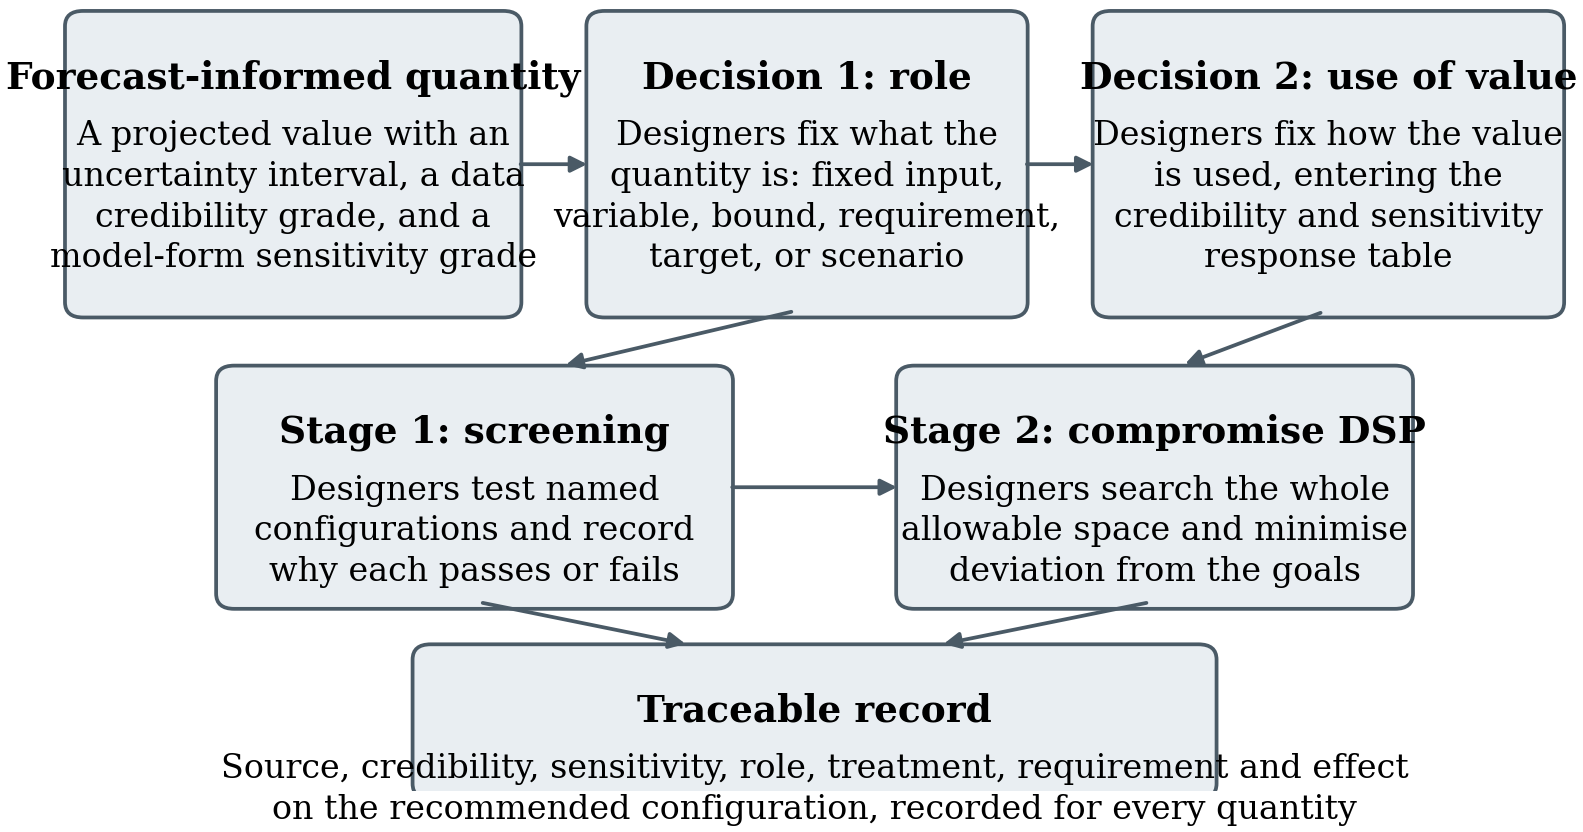

Figure 1. The procedure as a whole (paper Section 3).



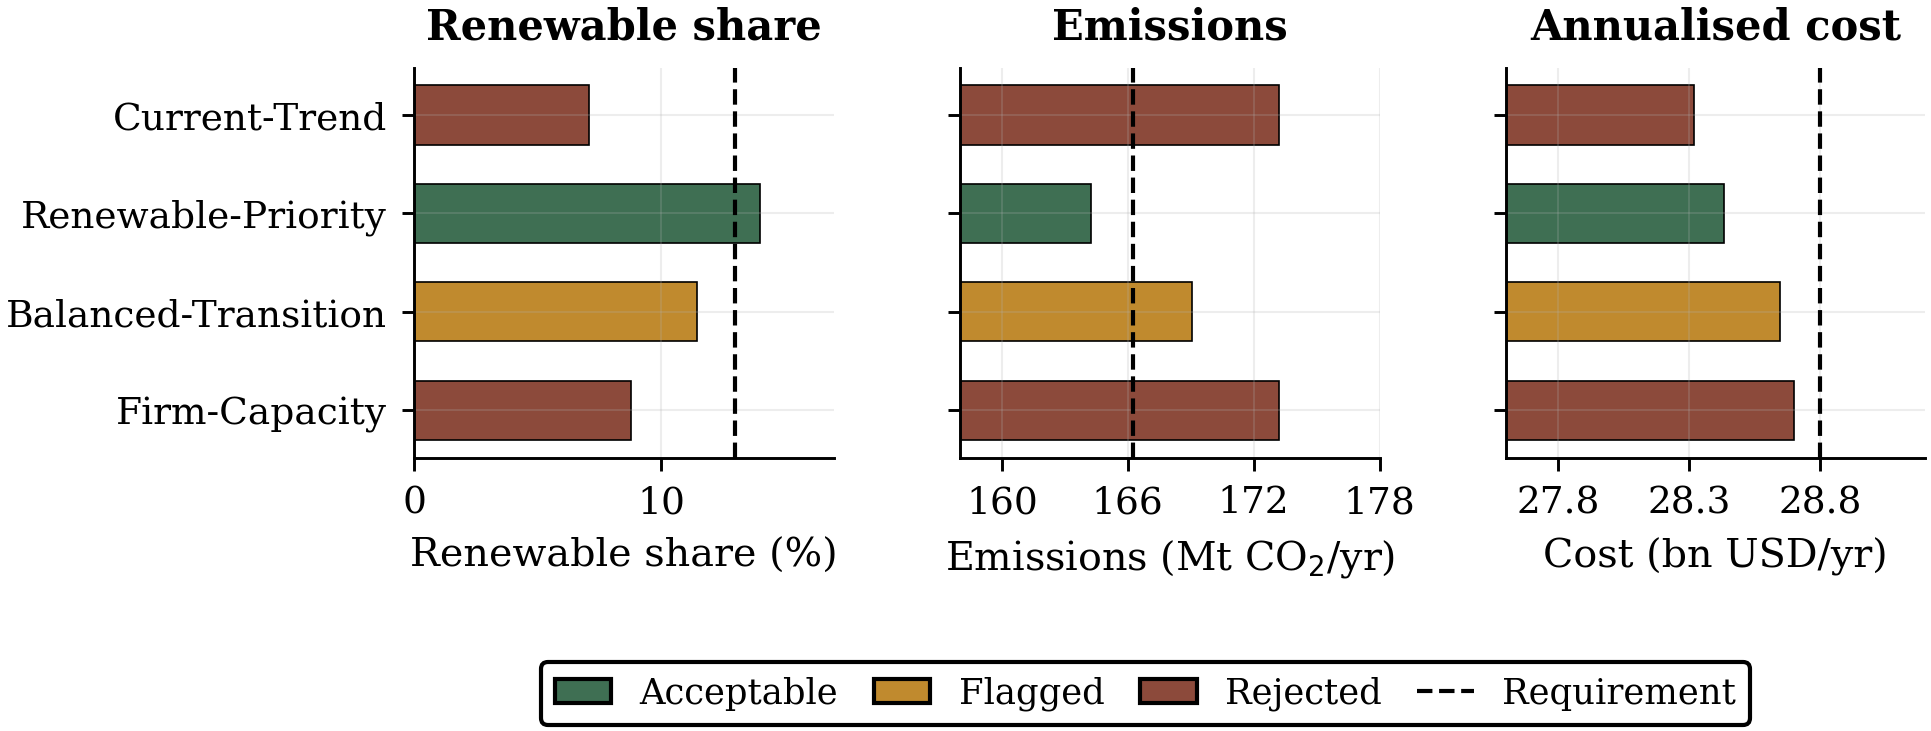

Figure 2. Stage 1 screening of the four candidate configurations (paper Section 7.1).



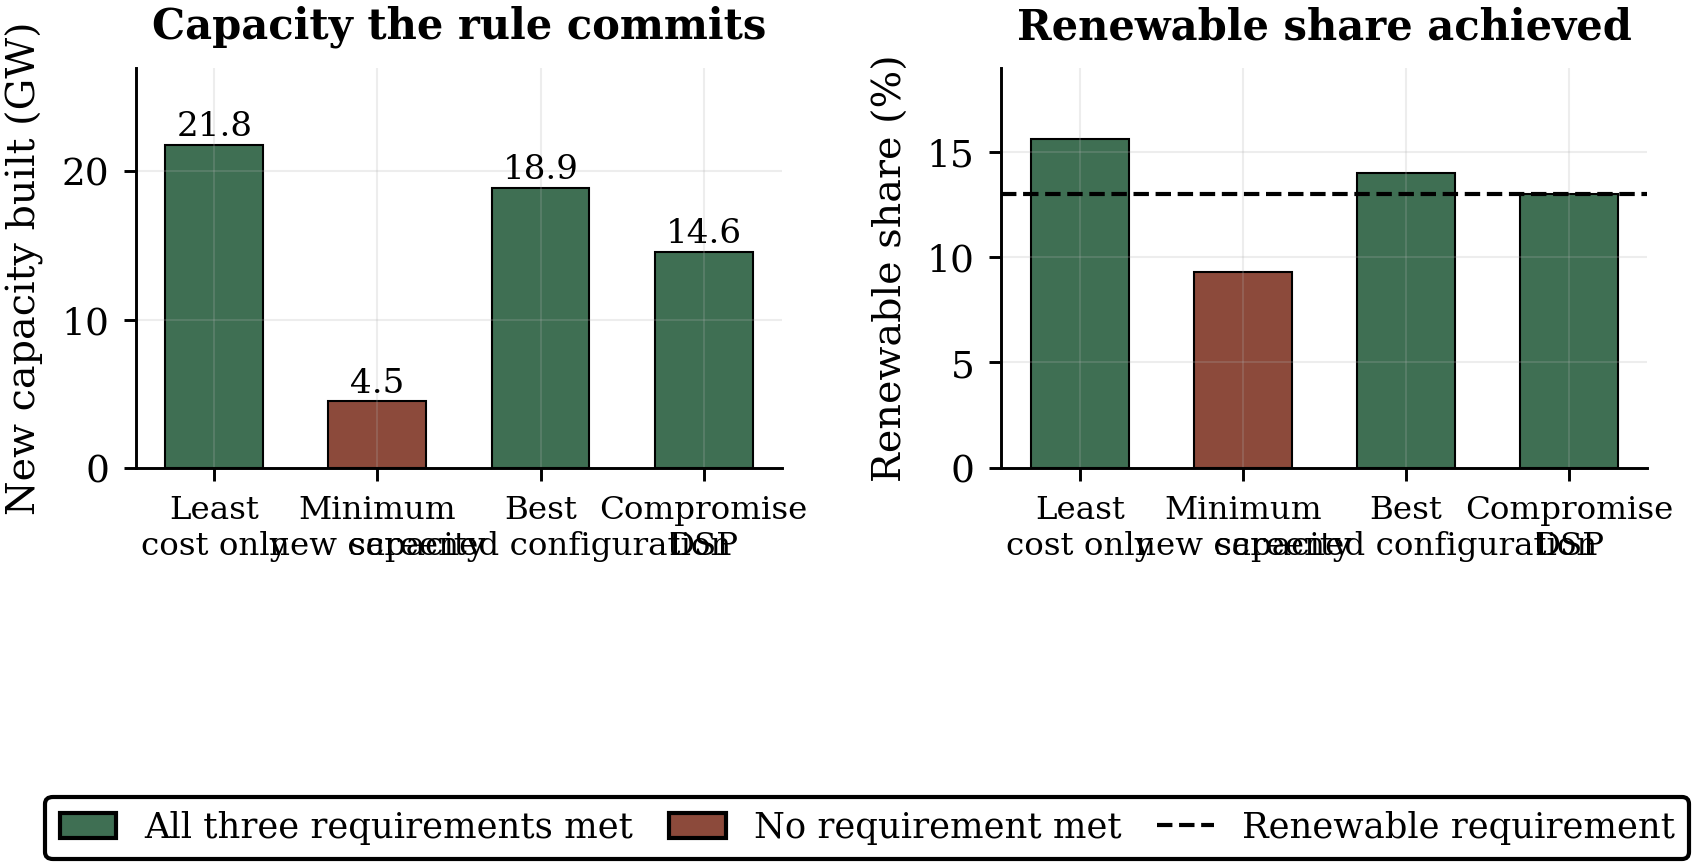

Figure 3. Comparison with four simpler decision rules (paper Section 7.3).



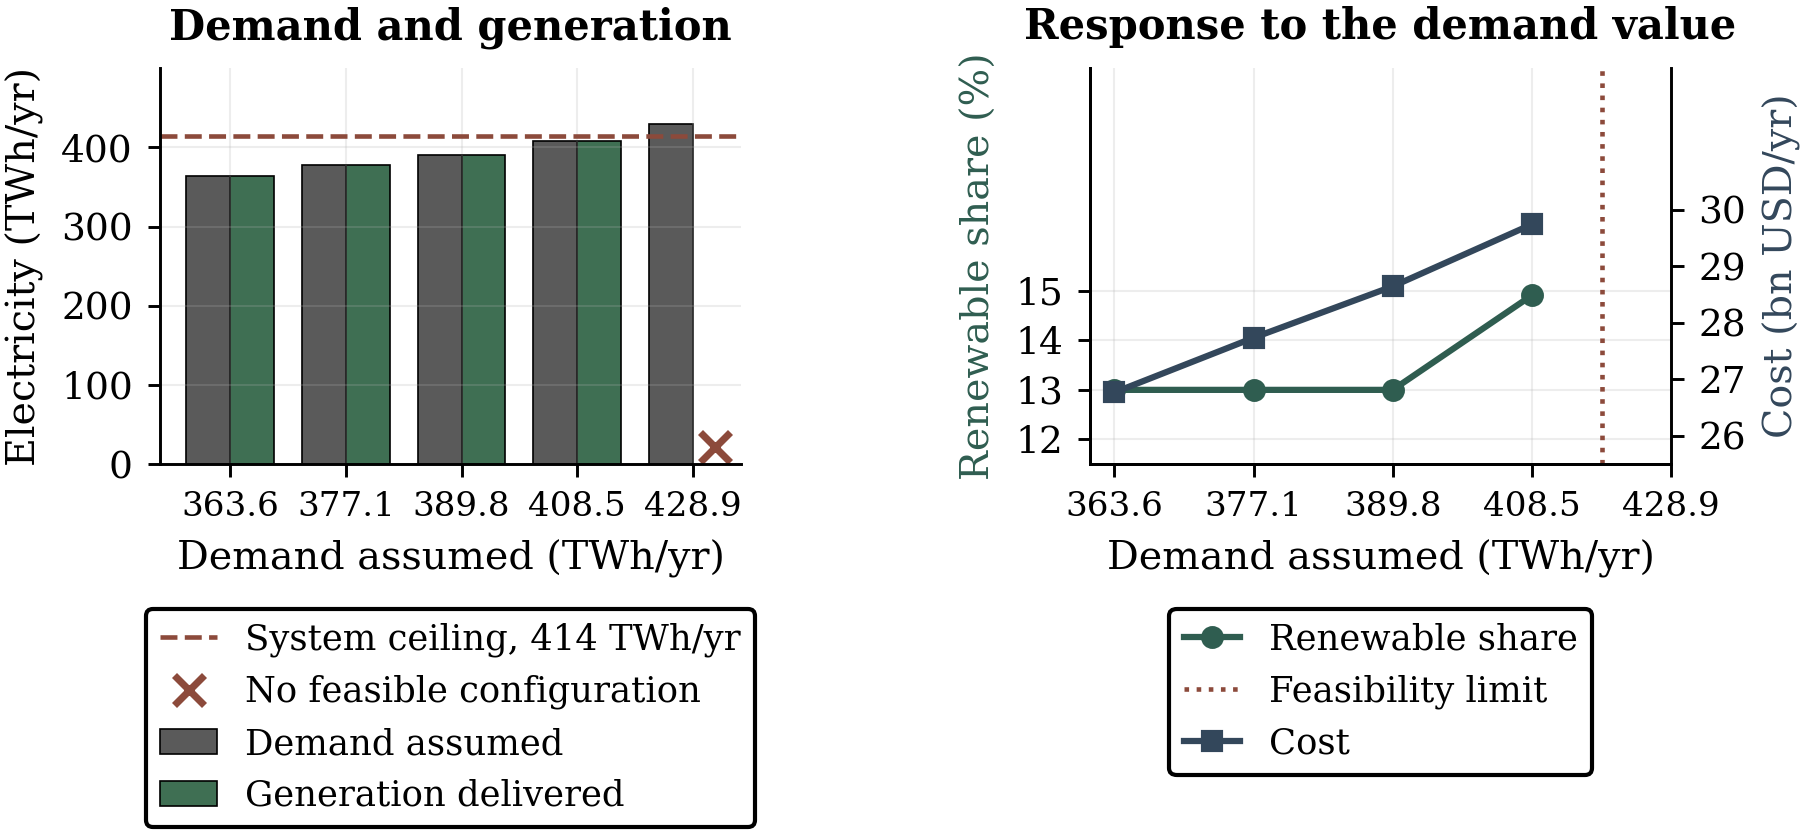

Figure 4. Five demand levels and the limit of feasibility (paper Section 7.5).



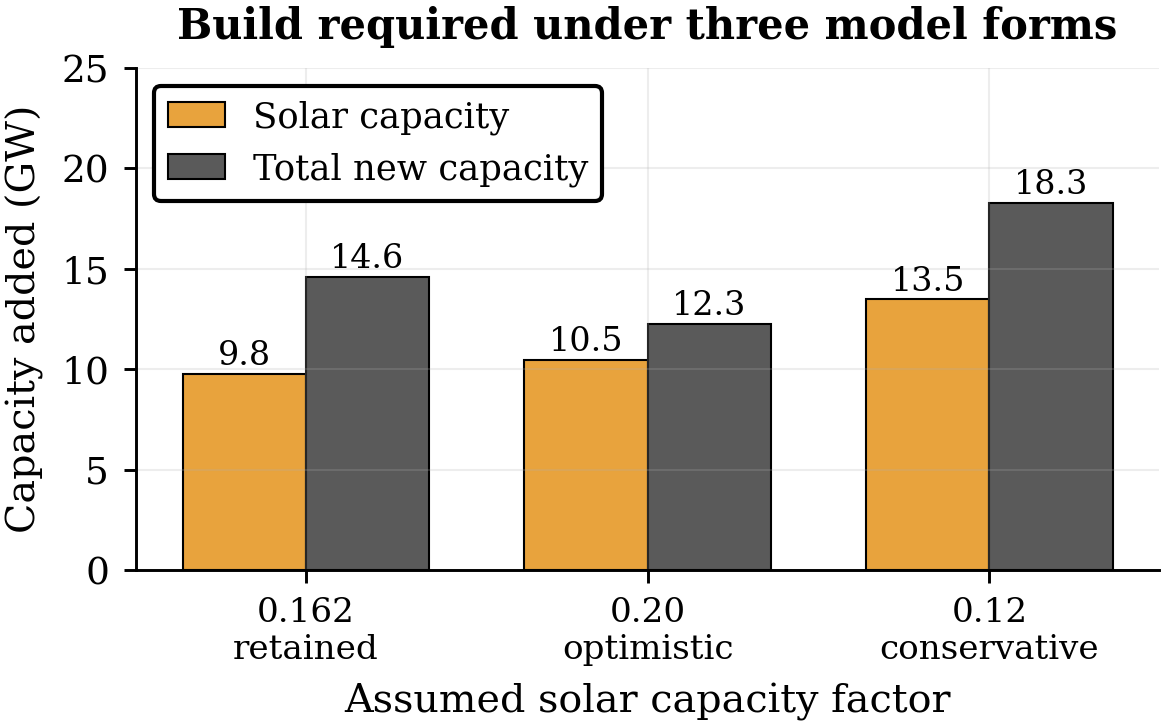

Figure 5. Build required under three solar model forms (paper Section 7.6).



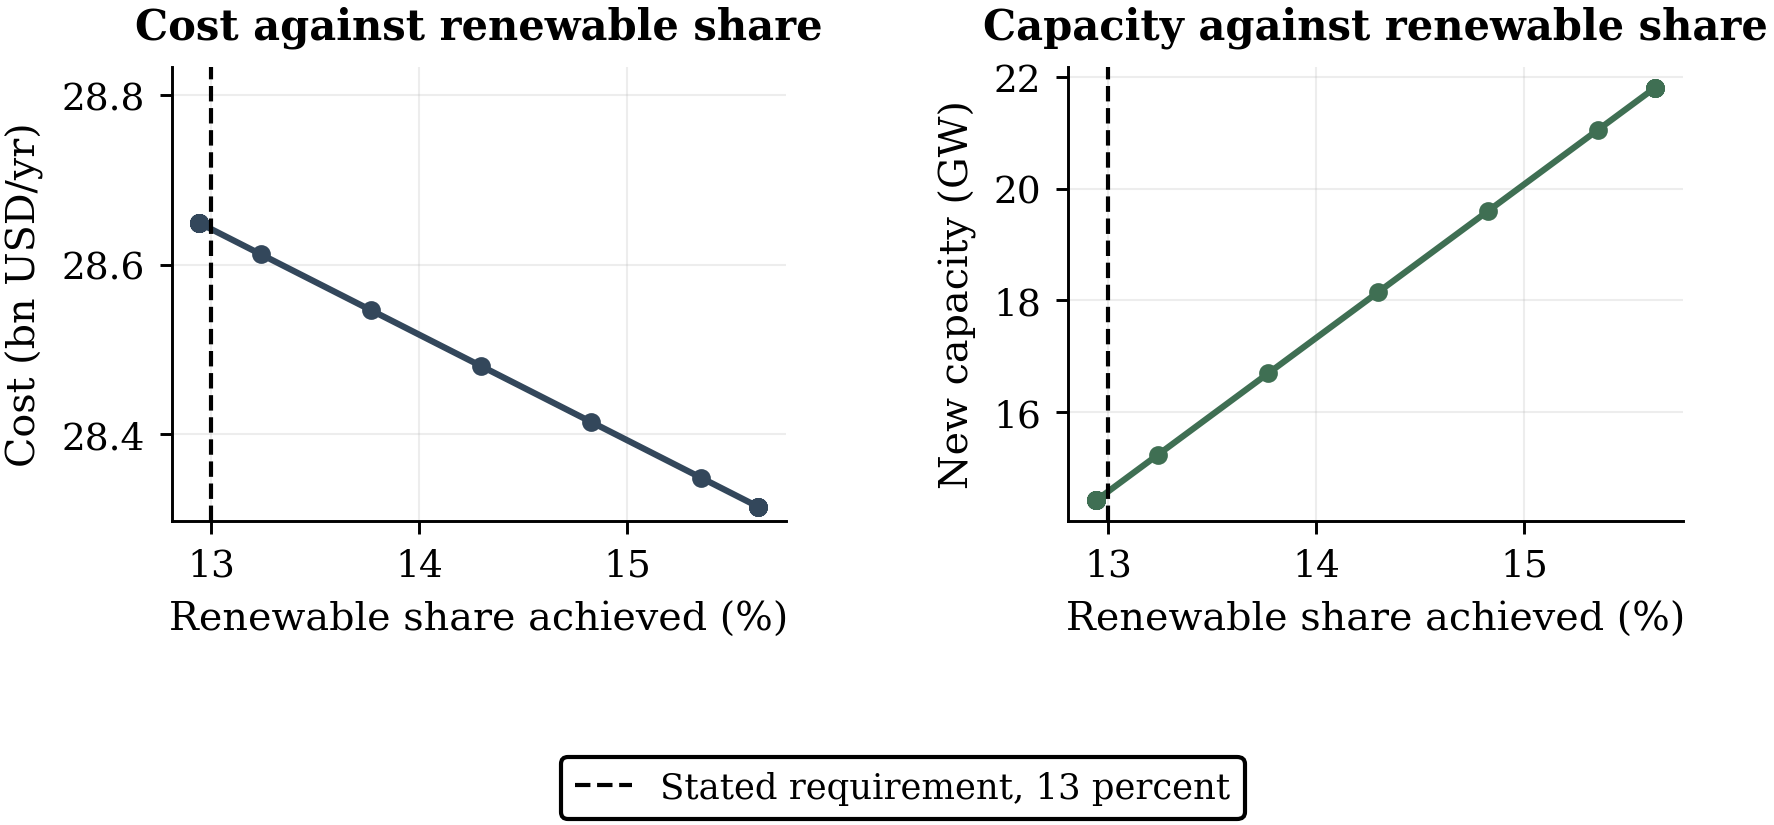

Figure 6. The trade-off frontier (paper Section 7.7).



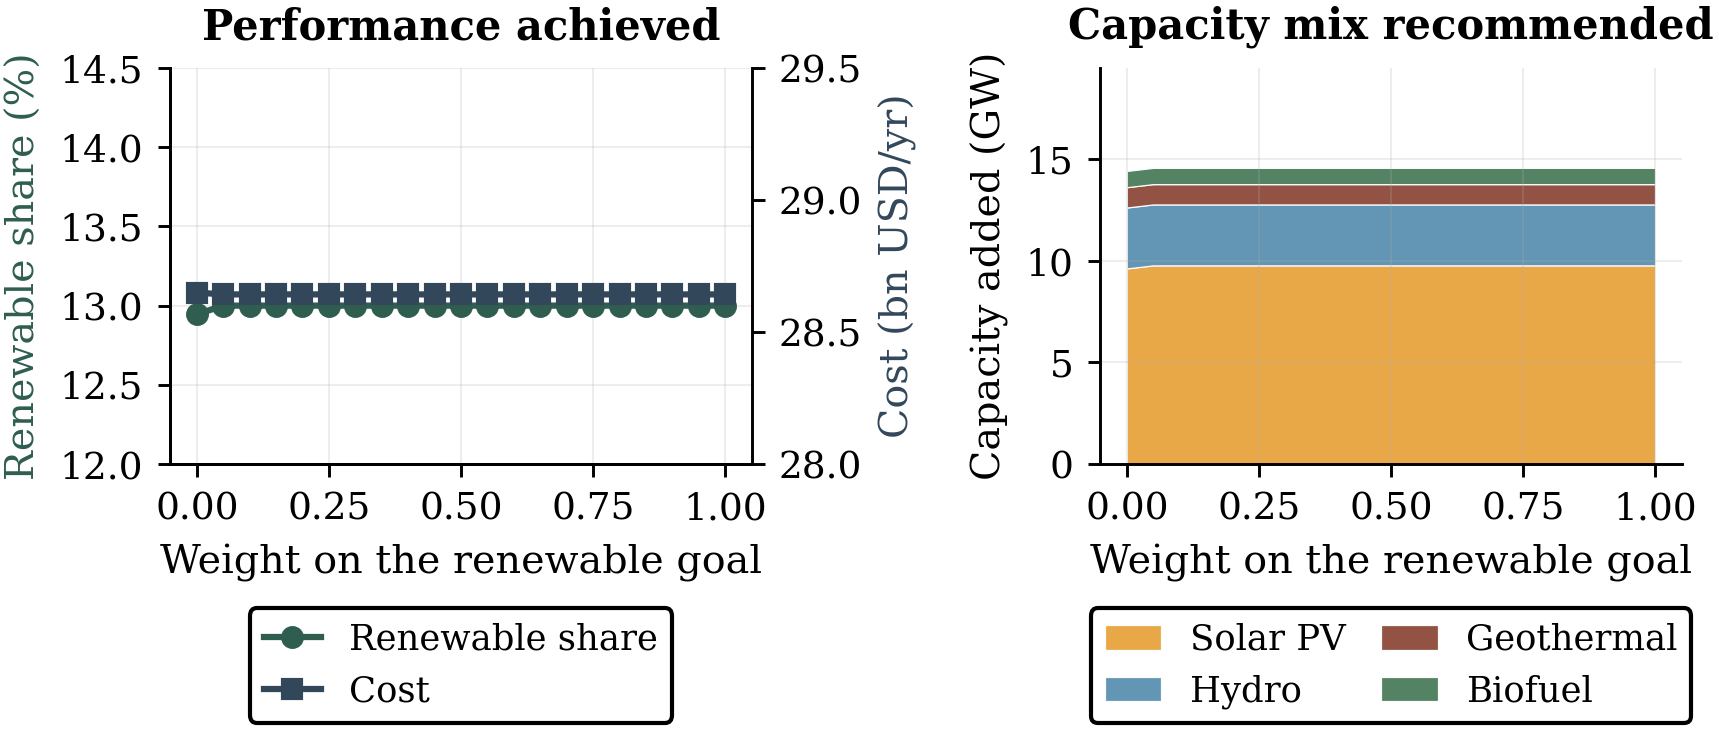

Figure 7. The effect of the goal weights (paper Section 7.8).



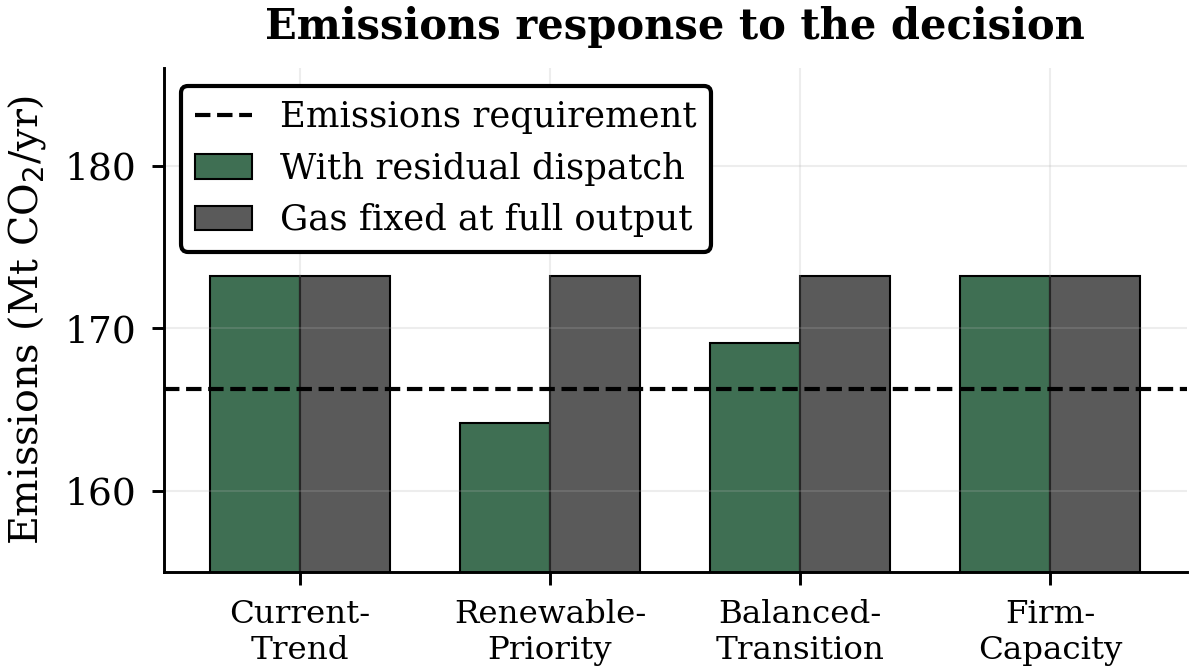

Figure 8. What residual dispatch contributes (paper Section 7.9).



In [20]:
import subprocess, sys
subprocess.run([sys.executable, "make_figures.py"], check=True)

from IPython.display import Image, display as disp
captions = [
 ("figs/fig_procedure.png", "Figure 1. The procedure as a whole (paper Section 3)."),
 ("figs/fig_screening.png", "Figure 2. Stage 1 screening of the four candidate configurations (paper Section 7.1)."),
 ("figs/fig_baselines.png", "Figure 3. Comparison with four simpler decision rules (paper Section 7.3)."),
 ("figs/fig_demand.png",    "Figure 4. Five demand levels and the limit of feasibility (paper Section 7.5)."),
 ("figs/fig_solar.png",     "Figure 5. Build required under three solar model forms (paper Section 7.6)."),
 ("figs/fig_frontier.png",  "Figure 6. The trade-off frontier (paper Section 7.7)."),
 ("figs/fig_weights.png",   "Figure 7. The effect of the goal weights (paper Section 7.8)."),
 ("figs/fig_ablation.png",  "Figure 8. What residual dispatch contributes (paper Section 7.9)."),
]
for path, cap in captions:
    disp(Image(filename=path)); print(cap); print()

## Closing

Through this procedure, designers connect forecast-informed quantities, evidence about data
credibility and model-form sensitivity, and stakeholder-defined requirements to a
configuration decision, and keep the path from each source to its effect on the outcome open
to inspection. We used the compromise Decision Support Problem as the formal satisficing
construct. Researchers and designers may apply the same information-mapping principles with
other satisficing or threshold-based approaches that distinguish rigid requirements from
desired performance targets.

Repository: https://github.com/RS-010806/forecast-informed-cdsp